In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# Set visualization parameters for dissertation-quality figures
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Load exported model assets
try:
    loaded_ensemble = joblib.load("../models/champion_recovery_ensemble.pkl")
    model_features = joblib.load("../models/ensemble_feature_columns.pkl")
    print(f"[SUCCESS] Exported ensemble model loaded perfectly. Feature count: {len(model_features)}")
except FileNotFoundError:
    print("[ERROR] Ensure your '.pkl' files are present in the working directory.")

# 2. Load master engineered dataset to map original indices, categories, and targets
# Ensure this matches your final notebook data path
df_master = pd.read_csv("../data/processed/final_dataset.csv")

# 3. Target Constants matching your Option A pipeline setup exactly
Y_MAX_CONSTANT = df_master['recovery_time_hours'].max() + 1

[SUCCESS] Exported ensemble model loaded perfectly. Feature count: 18


In [25]:
X_eval = df_master[model_features].copy()
y_true = df_master['recovery_time_hours'].copy()

# 4. Generate Predictions and Invert via Option A formula
pred_log = loaded_ensemble.predict(X_eval)
y_pred = Y_MAX_CONSTANT - np.expm1(pred_log)

# 5. Build Master Diagnostic DataFrame
error_df = pd.DataFrame({
    'Actual_Hours': y_true,
    'Predicted_Hours': y_pred,
    'Residual': y_true - y_pred,         # Positive = Underprediction, Negative = Overprediction
    'Absolute_Error': np.abs(y_true - y_pred)
})

print("\n[INFO] Reverse-engineering one-hot encoded flags back to text categories...")

def extract_recovery_status(row):
    if 'recovery_status_Elevated Fatigue' in row and row['recovery_status_Elevated Fatigue'] == 1:
        return 'Elevated Fatigue'
    elif 'recovery_status_Optimal Recovery' in row and row['recovery_status_Optimal Recovery'] == 1:
        return 'Optimal Recovery'
    else:
        return 'Baseline/Delayed Recovery' # The dropped dummy reference category

def extract_sport_type(row):
    if 'sport_type_Soccer' in row and row['sport_type_Soccer'] == 1:
        return 'Soccer'
    elif 'sport_type_Track' in row and row['sport_type_Track'] == 1:
        return 'Track'
    elif 'sport_type_Other' in row and row['sport_type_Other'] == 1:
        return 'Other'
    else:
        return 'Baseline Sport' # The dropped dummy reference category

# Apply mapping transformations across the dataset rows
error_df['reconstructed_recovery_status'] = df_master.apply(extract_recovery_status, axis=1)
error_df['reconstructed_sport_type'] = df_master.apply(extract_sport_type, axis=1)

if 'gender_Male' in df_master.columns:
    error_df['gender'] = df_master['gender_Male'].apply(lambda x: 'Male' if x == 1 else 'Female')
if 'training_load' in df_master.columns:
    error_df['training_load'] = df_master['training_load']

print(f"[SUCCESS] Error diagnostics dataframe compiled across {len(error_df)} evaluation records.")


[INFO] Reverse-engineering one-hot encoded flags back to text categories...
[SUCCESS] Error diagnostics dataframe compiled across 15420 evaluation records.


In [21]:
under_preds = error_df[error_df['Residual'] > 0]
over_preds = error_df[error_df['Residual'] < 0]

print("=" * 70)
print("🔬 DIAGNOSTIC METRIC: DIRECTIONAL BIAS ANALYSIS")
print("=" * 70)
print(f"Underprediction Frequency : {len(under_preds)} rows ({len(under_preds)/len(error_df)*100:.1f}%)")
print(f"Avg Underpredict Magnitude : {under_preds['Absolute_Error'].mean():.2f} Hours (Model underestimated recovery)")
print(f"Overprediction Frequency  : {len(over_preds)} rows ({len(over_preds)/len(error_df)*100:.1f}%)")
print(f"Avg Overpredict Magnitude  : {over_preds['Absolute_Error'].mean():.2f} Hours (Model overestimated recovery)")
print("-" * 70)

# Calculate skewness of the residuals
residual_skew = stats.skew(error_df['Residual'])
print(f"Residual Distribution Skewness Coefficient: {residual_skew:.4f}")
if abs(residual_skew) < 0.5:
    print("Interpretation: Residuals are highly symmetric. Option A target transformation successfully neutralized original skew variance.")
else:
    print("Interpretation: Minor directional tail skew remains within extreme outliers.")
print("=" * 70)

🔬 DIAGNOSTIC METRIC: DIRECTIONAL BIAS ANALYSIS
Underprediction Frequency : 7184 rows (46.6%)
Avg Underpredict Magnitude : 4.44 Hours (Model underestimated recovery)
Overprediction Frequency  : 8236 rows (53.4%)
Avg Overpredict Magnitude  : 2.72 Hours (Model overestimated recovery)
----------------------------------------------------------------------
Residual Distribution Skewness Coefficient: 1.0705
Interpretation: Minor directional tail skew remains within extreme outliers.


/var/folders/_w/m30405jx1mj3bdm7ym090rc80000gn/T/ipykernel_2531/1946820008.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_df, x='Prediction_Bias_Type', y='Absolute_Error', ax=ax2,


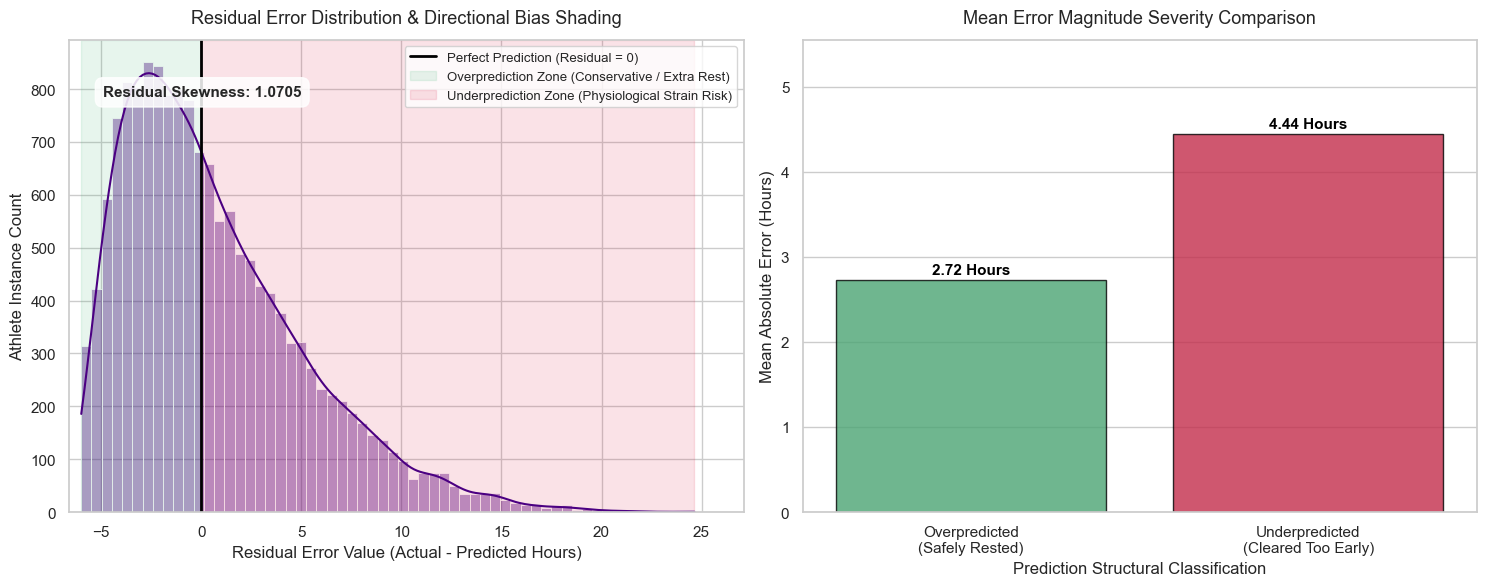

In [28]:
# Create a high-resolution side-by-side diagnostic canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot A: Residual Distribution (Skewness & Bias Directionality) ---
# Generate histogram with continuous Kernel Density estimate overlay
sns.histplot(data=error_df, x='Residual', kde=True, ax=ax1, color='indigo', bins=60, alpha=0.4)

# Draw a bold vertical baseline at perfect prediction (Residual = 0)
ax1.axvline(0, color='black', linestyle='-', linewidth=2, label='Perfect Prediction (Residual = 0)')

# Dynamic boundary mapping for structural shading
min_res, max_res = error_df['Residual'].min(), error_df['Residual'].max()
ax1.axvspan(min_res, 0, color='mediumseagreen', alpha=0.12, label='Overprediction Zone (Conservative / Extra Rest)')
ax1.axvspan(0, max_res, color='crimson', alpha=0.12, label='Underprediction Zone (Physiological Strain Risk)')

# Embed the calculated statistical skewness value directly into the plot area
ax1.text(0.05, 0.88, f"Residual Skewness: {residual_skew:.4f}", transform=ax1.transAxes, 
         fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.85, boxstyle='round,pad=0.5'))

ax1.set_title('Residual Error Distribution & Directional Bias Shading', fontsize=13, pad=12)
ax1.set_xlabel('Residual Error Value (Actual - Predicted Hours)')
ax1.set_ylabel('Athlete Instance Count')
ax1.set_xlim(min_res * 1.1, max_res * 1.1)
ax1.legend(loc='upper right', fontsize=9.5)

# --- Plot B: Severity Magnitude Comparison (Under vs Overprediction Bar Chart) ---
# Construct a temporary descriptive categorical flag purely for plotting purposes
error_df['Prediction_Bias_Type'] = error_df['Residual'].apply(
    lambda x: 'Underpredicted\n(Cleared Too Early)' if x > 0 else 'Overpredicted\n(Safely Rested)'
)

# Render mean absolute error magnitudes grouped by bias categories
sns.barplot(data=error_df, x='Prediction_Bias_Type', y='Absolute_Error', ax=ax2, 
            palette={'Underpredicted\n(Cleared Too Early)': 'crimson', 
                     'Overpredicted\n(Safely Rested)': 'mediumseagreen'}, 
            alpha=0.8, edgecolor='black', errorbar=None)

# Calculate exact heights to print automated metric value callouts above the bars
for p in ax2.patches:
    bar_height = p.get_height()
    ax2.text(p.get_x() + p.get_width()/2., bar_height + 0.04, f'{bar_height:.2f} Hours', 
             ha="center", va="bottom", fontsize=11, fontweight='bold', color='black')

ax2.set_title('Mean Error Magnitude Severity Comparison', fontsize=13, pad=12)
ax2.set_xlabel('Prediction Structural Classification')
ax2.set_ylabel('Mean Absolute Error (Hours)')

# Apply an elegant padding ceiling above the highest printed label
ax2.set_ylim(0, error_df.groupby('Prediction_Bias_Type')['Absolute_Error'].mean().max() * 1.25)

# Drop the temporary column immediately to keep the master error_df dataframe pristine
error_df.drop(columns=['Prediction_Bias_Type'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()


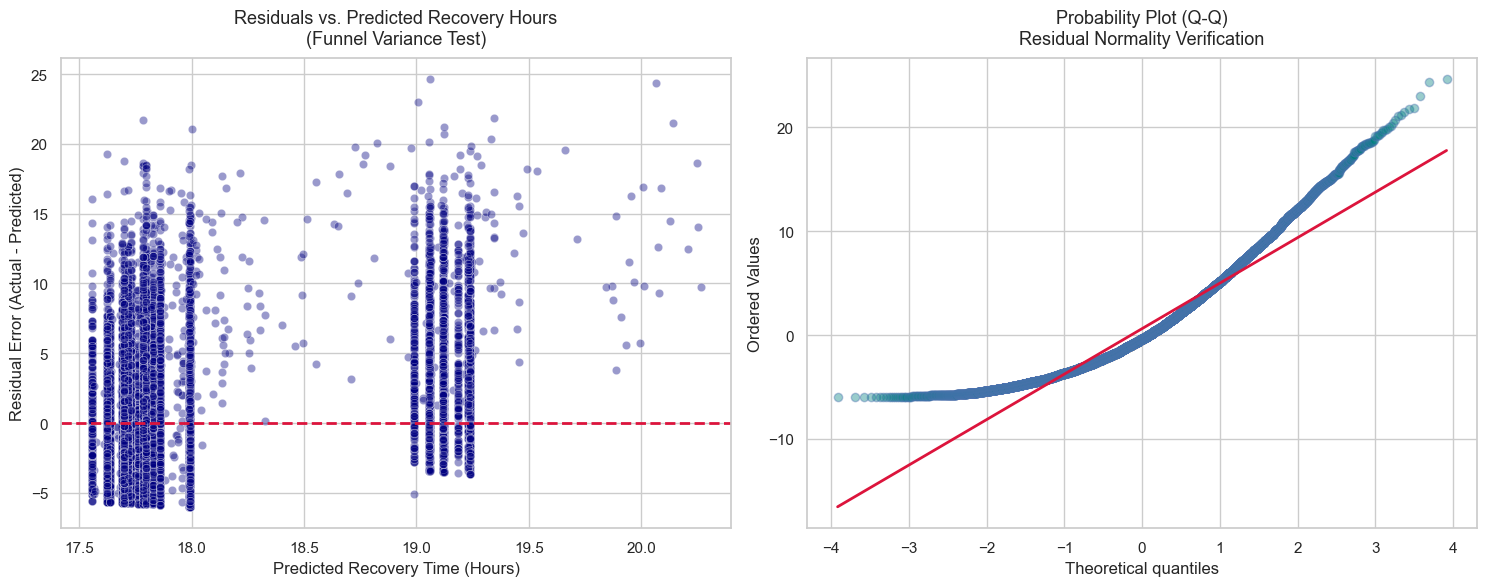

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Heteroscedasticity Visual Assessment (Funnel Test)
sns.scatterplot(data=error_df, x='Predicted_Hours', y='Residual', alpha=0.4, color='navy', ax=ax1)
ax1.axhline(0, color='crimson', linestyle='--', linewidth=2)
ax1.set_title('Residuals vs. Predicted Recovery Hours\n(Funnel Variance Test)', fontsize=13, pad=10)
ax1.set_xlabel('Predicted Recovery Time (Hours)')
ax1.set_ylabel('Residual Error (Actual - Predicted)')

# Plot 2: Fixed Q-Q Plot for Residual Normality using 'norm'
stats.probplot(error_df['Residual'], dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('teal')
ax2.get_lines()[0].set_alpha(0.4)
ax2.get_lines()[1].set_color('crimson')
ax2.get_lines()[1].set_linewidth(2)
ax2.set_title('Probability Plot (Q-Q)\nResidual Normality Verification', fontsize=13, pad=10)

plt.tight_layout()
plt.show()

In [26]:
# %% [markdown]
# ### Phase 4: Stratified Error Mapping Across Reconstructed Cohorts

# %%
print("=" * 80)
print("🔬 COHORT METRIC: STRATIFIED ERROR LOSS TABLE")
print("=" * 80)

# 1. Stratification Across your GMM Recovery Status States
if 'reconstructed_recovery_status' in error_df.columns:
    gmm_group = error_df.groupby('reconstructed_recovery_status').agg(
        Sample_Count=('Absolute_Error', 'count'),
        Mean_Absolute_Error_Hours=('Absolute_Error', 'mean'),
        Root_Mean_Squared_Error_Hours=('Residual', lambda x: np.sqrt(mean_squared_error(np.zeros_like(x), x))),
        Max_Peak_Error_Hours=('Absolute_Error', 'max')
    ).reset_index()
    
    gmm_group = gmm_group.rename(columns={'reconstructed_recovery_status': 'GMM_Recovery_Status_Cohort'})
    print("\n[A] Error Loss Metrics Bounded by GMM Recovery Status Phenotypes:")
    print(gmm_group.to_string(index=False))
else:
    print("\n[ERROR] Reconstructed recovery status column missing.")

# 2. Stratification Across Sport Types
if 'reconstructed_sport_type' in error_df.columns:
    sport_group = error_df.groupby('reconstructed_sport_type').agg(
        Sample_Count=('Absolute_Error', 'count'),
        Mean_Absolute_Error_Hours=('Absolute_Error', 'mean'),
        Root_Mean_Squared_Error_Hours=('Residual', lambda x: np.sqrt(mean_squared_error(np.zeros_like(x), x))),
        Max_Peak_Error_Hours=('Absolute_Error', 'max')
    ).reset_index()
    
    sport_group = sport_group.rename(columns={'reconstructed_sport_type': 'Sport_Type_Cohort'})
    print("\n[B] Error Distribution Across Athlete Sports Categories:")
    print(sport_group.to_string(index=False))

print("=" * 80)


🔬 COHORT METRIC: STRATIFIED ERROR LOSS TABLE

[A] Error Loss Metrics Bounded by GMM Recovery Status Phenotypes:
GMM_Recovery_Status_Cohort  Sample_Count  Mean_Absolute_Error_Hours  Root_Mean_Squared_Error_Hours  Max_Peak_Error_Hours
 Baseline/Delayed Recovery          4715                   4.026695                       5.323613             24.641135
          Elevated Fatigue          2377                   3.527366                       4.613424             21.177368
          Optimal Recovery          8328                   3.237810                       4.116678             21.714628

[B] Error Distribution Across Athlete Sports Categories:
Sport_Type_Cohort  Sample_Count  Mean_Absolute_Error_Hours  Root_Mean_Squared_Error_Hours  Max_Peak_Error_Hours
   Baseline Sport          4059                   3.460413                       4.476915             22.992441
            Other          2377                   3.527366                       4.613424             21.177368
          

/var/folders/_w/m30405jx1mj3bdm7ym090rc80000gn/T/ipykernel_2531/194305981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


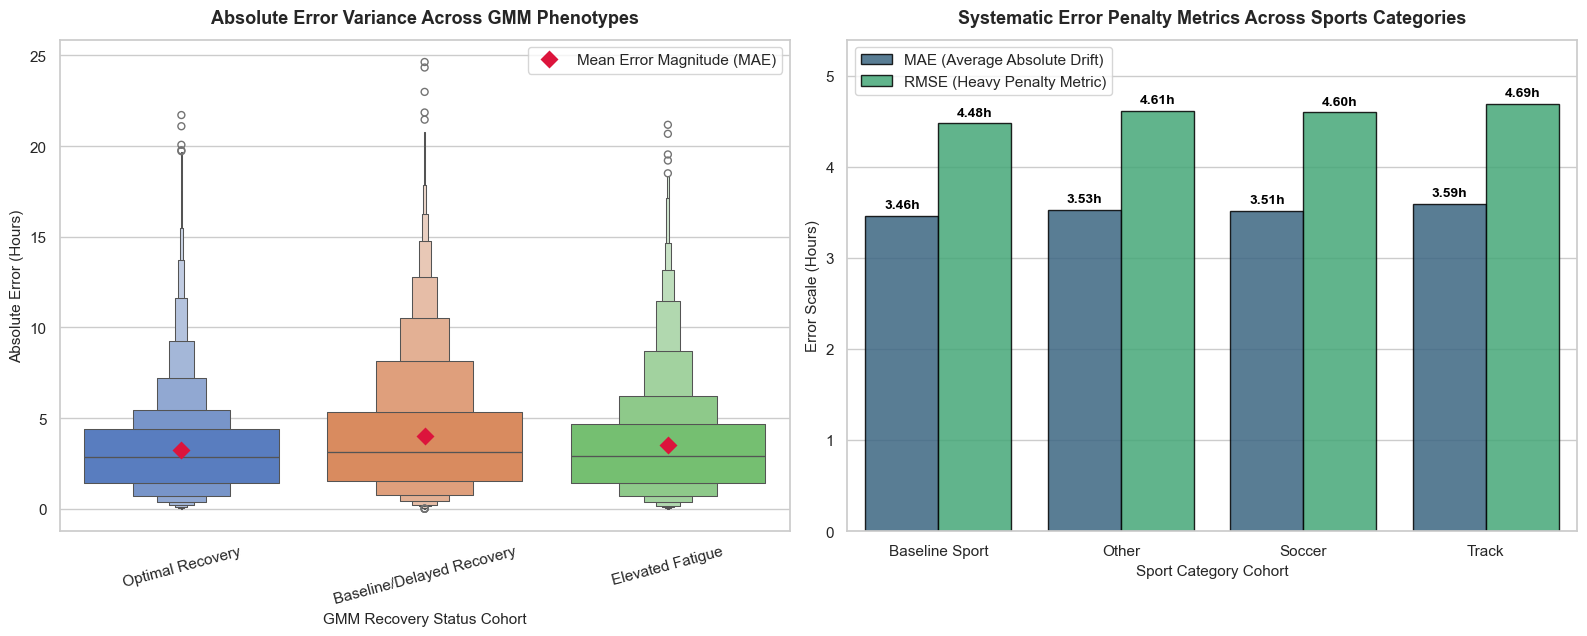

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# --- Plot A: Box/Distribution Plot for GMM Status Cohorts ---
# Using boxenplot to cleanly visualize the dense centers and the tail distributions/outliers
sns.boxenplot(
    data=error_df, 
    x='reconstructed_recovery_status', 
    y='Absolute_Error', 
    ax=ax1,
    palette='muted',
    showfliers=True
)
# Add a point plot overlay to explicitly mark the Mean value for examiners
sns.pointplot(
    data=error_df, 
    x='reconstructed_recovery_status', 
    y='Absolute_Error', 
    ax=ax1, 
    estimator='mean',
    color='crimson', 
    markers='D', 
    linestyles='none',
    label='Mean Error Magnitude (MAE)'
)

ax1.set_title('Absolute Error Variance Across GMM Phenotypes', fontsize=13, pad=12, fontweight='bold')
ax1.set_xlabel('GMM Recovery Status Cohort', fontsize=11)
ax1.set_ylabel('Absolute Error (Hours)', fontsize=11)
ax1.tick_params(axis='x', rotation=15)
ax1.legend(loc='upper right')

# --- Plot B: Grouped Bar Chart comparing MAE vs RMSE by Sport Category ---
if 'sport_group' in locals() or 'sport_group' in globals():
    # Melt the pre-calculated sport_group dataframe to wide/long form for seaborn grouped bars
    sport_melted = pd.melt(
        sport_group, 
        id_vars=['Sport_Type_Cohort'], 
        value_vars=['Mean_Absolute_Error_Hours', 'Root_Mean_Squared_Error_Hours'],
        var_name='Error_Metric', 
        value_name='Hours'
    )
    
    # Standardize the naming conventions for the chart legend
    sport_melted['Error_Metric'] = sport_melted['Error_Metric'].replace({
        'Mean_Absolute_Error_Hours': 'MAE (Average Absolute Drift)',
        'Root_Mean_Squared_Error_Hours': 'RMSE (Heavy Penalty Metric)'
    })
    
    sns.barplot(
        data=sport_melted, 
        x='Sport_Type_Cohort', 
        y='Hours', 
        hue='Error_Metric', 
        ax=ax2, 
        palette='viridis',
        edgecolor='black',
        alpha=0.85
    )
    
    # Annotate numeric values exactly on top of the bars
    for p in ax2.patches:
        height = p.get_height()
        if height > 0: # Ensure we don't label empty space patches
            ax2.text(
                p.get_x() + p.get_width()/2., 
                height + 0.05, 
                f'{height:.2f}h', 
                ha="center", va="bottom", fontsize=10, color='black', fontweight='semibold'
            )
            
    ax2.set_title('Systematic Error Penalty Metrics Across Sports Categories', fontsize=13, pad=12, fontweight='bold')
    ax2.set_xlabel('Sport Category Cohort', fontsize=11)
    ax2.set_ylabel('Error Scale (Hours)', fontsize=11)
    ax2.set_ylim(0, sport_melted['Hours'].max() * 1.15)
    ax2.legend(loc='upper left', frameon=True)
else:
    ax2.text(0.5, 0.5, "Please run Phase 4 table computation cell first\nto populate sport_group variables.", 
             ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.show()